In [48]:
data1 = [72, 51, 146, 30, 28, 88, 92, 47, 52, 68, 80, 34, 28, 105, 76, 93, 55, 40, 62, 37, 88, 30, 122, 46, 35, 29, 77, 40, 71, 57]
data2 = [88, 130, 255, 56, 0, 38, 167, 188, 132, 147, 78, 80, 40, 170, 280, 46, 174, 182, 75, 89, 103, 230, 380, 57, 55, 90, 96, 102, 78, 69, 53, 160, 195, 245, 60, 94, 145, 115, 225, 71]

{'Q1': 37, 'Median': 56.0, 'Q3': 80, 'Lower whisker': 28, 'Upper whisker': 144.5, 'Outliers': array([146])}
{'Q1': 70.0, 'Median': 99.0, 'Q3': 172.0, 'Lower whisker': 0, 'Upper whisker': 325.0, 'Outliers': array([380])}


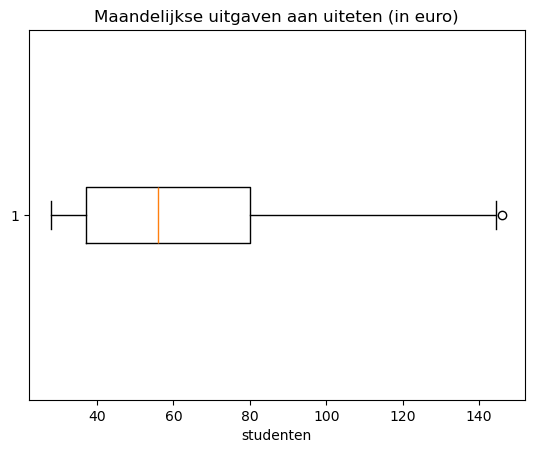

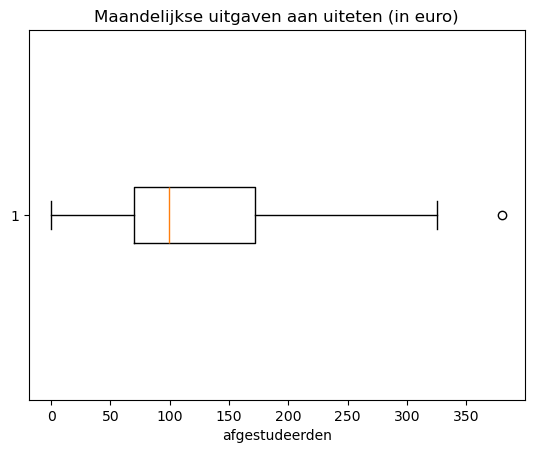

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PRIMARY_COLOR = "skyblue"

def custom_boxplot(data, title, xlabel, ax=None):
    """
    Create a boxplot where:
    1. The median is the mean of the two middle values for even n.
    2. Q1 and Q3 are medians of the lower and upper halves (exclusive of the overall median if n is odd).
    3. Whiskers extend to the most extreme points within 1.5 * IQR from Q1 and Q3.
    """
    data = np.sort(np.asarray(data))
    n = len(data)

    # --- Median ---
    if n % 2 == 0:
        median = np.mean(data[(n//2 - 1):(n//2 + 1)])
        lower_half = data[:(n//2)]
        upper_half = data[(n//2):]
    else:
        median = data[n//2]
        lower_half = data[:(n//2)]
        upper_half = data[(n//2 + 1):]

    # --- Q1 and Q3 ---
    def median_custom(x):
        m = len(x)
        if m % 2 == 0:
            return np.mean(x[(m//2 - 1):(m//2 + 1)])
        else:
            return x[m//2]

    Q1 = median_custom(lower_half)
    Q3 = median_custom(upper_half)
    IQR = Q3 - Q1

    # --- Whiskers ---
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    lower_whisker = max(lower_bound, np.min(data))
    upper_whisker = min(upper_bound, np.max(data))

    # --- Outliers ---
    outliers = data[(data < lower_whisker) | (data > upper_whisker)]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots()

    ax.bxp([{
        'med': median,
        'q1': Q1,
        'q3': Q3,
        'whislo': lower_whisker,
        'whishi': upper_whisker,
        'fliers': outliers
    }], 
    vert=False,
    showfliers=True)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    return {'Q1': Q1, 'Median': median, 'Q3': Q3,
            'Lower whisker': lower_whisker, 'Upper whisker': upper_whisker,
            'Outliers': outliers}

# Example usage
# data = [25, 32, 45, 60, 65, 66, 70, 75, 80, 82]
for dataset, label in [(data1, "studenten"), (data2, "afgestudeerden")]:
    result = custom_boxplot(dataset, title="Maandelijkse uitgaven aan uiteten (in euro)", xlabel = label)
    print(result)
    plt.savefig(f"./Figures/opg2.20a_{label}.png")


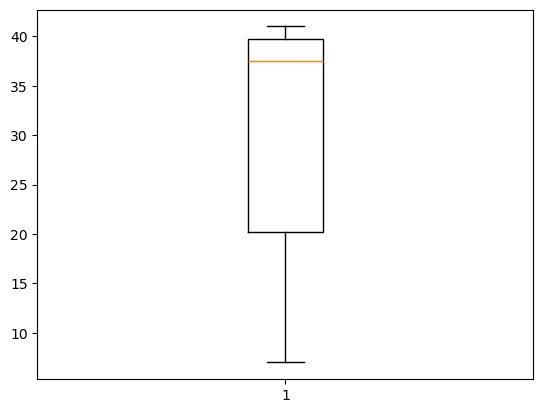

In [50]:
example = [7, 15, 36, 39, 40, 41]
bp = plt.boxplot([example])
bp["boxes"]

<Axes: >

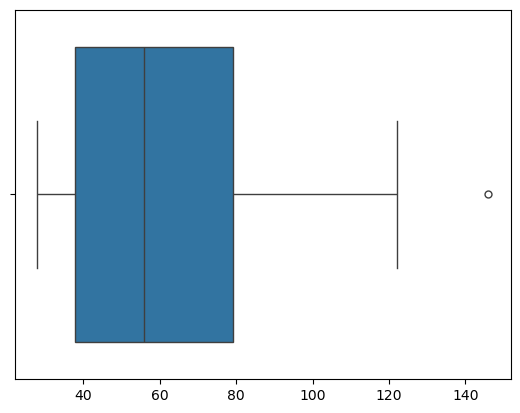

In [51]:
import seaborn as sns
sns.boxplot(x=data1, y=None, hue=None, data=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, width=0.8, dodge=True, fliersize=5, linewidth=None, whis=1.5, ax=None)

In [52]:
import pandas as pd
df1 = pd.DataFrame(data1, columns=["VALUE"])
df1 = df1.sort_values(by="VALUE")
df1, df1.describe()

(    VALUE
 4      28
 12     28
 25     29
 3      30
 21     30
 11     34
 24     35
 19     37
 27     40
 17     40
 23     46
 7      47
 1      51
 8      52
 16     55
 29     57
 18     62
 9      68
 28     71
 0      72
 14     76
 26     77
 10     80
 20     88
 5      88
 6      92
 15     93
 13    105
 22    122
 2     146,
             VALUE
 count   30.000000
 mean    62.633333
 std     29.941879
 min     28.000000
 25%     37.750000
 50%     56.000000
 75%     79.250000
 max    146.000000)

In [53]:
df2 = pd.DataFrame(data2, columns=["VALUE"])
df2 = df2.sort_values(by="VALUE")
df2, df2.describe()

(    VALUE
 4       0
 5      38
 12     40
 15     46
 30     53
 24     55
 3      56
 23     57
 34     60
 29     69
 39     71
 18     75
 28     78
 10     78
 11     80
 0      88
 19     89
 25     90
 35     94
 26     96
 27    102
 20    103
 37    115
 1     130
 8     132
 36    145
 9     147
 31    160
 6     167
 13    170
 16    174
 17    182
 7     188
 32    195
 38    225
 21    230
 33    245
 2     255
 14    280
 22    380,
             VALUE
 count   40.000000
 mean   125.950000
 std     79.094864
 min      0.000000
 25%     70.500000
 50%     99.000000
 75%    171.000000
 max    380.000000)

In [54]:
df3 = pd.DataFrame([28,
29,
30,
30,
34,
35,
37,
40,
40,
46,
47,
51,
52], columns=["VALUE"])

df3 = df3.sort_values(by="VALUE")
df3, df3.describe()

(    VALUE
 0      28
 1      29
 2      30
 3      30
 4      34
 5      35
 6      37
 7      40
 8      40
 9      46
 10     47
 11     51
 12     52,
            VALUE
 count  13.000000
 mean   38.384615
 std     8.421584
 min    28.000000
 25%    30.000000
 50%    37.000000
 75%    46.000000
 max    52.000000)

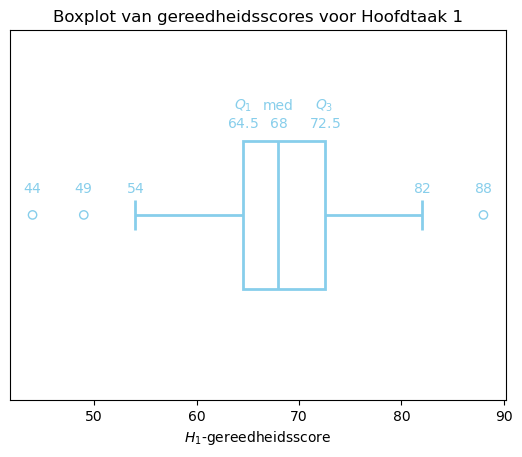

In [109]:
import numpy as np
import matplotlib.pyplot as plt

def median(x):
    n = len(x)
    mid = n // 2
    if n % 2 == 1:
        return x[mid]
    else:
        return (x[mid - 1] + x[mid]) / 2

def quartiles_tukey(data):
    x = np.sort(data)
    n = len(x)

    med = median(x)

    if n % 2 == 1:
        lower = x[:(n//2+1)]
        upper = x[n//2:]
    else:
        lower = x[:n//2]
        upper = x[n//2:]

    Q1 = median(lower)
    Q3 = median(upper)

    return Q1, med, Q3

def plot_horizontal_boxplot(data, title=None, xlabel=None, ylabel=None, filename=None):
    x = np.sort(data)

    Q1, med, Q3 = quartiles_tukey(x)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    non_outliers = x[(x >= lower_fence) & (x <= upper_fence)]
    outliers = x[(x < lower_fence) | (x > upper_fence)]

    whisker_low = non_outliers.min()
    whisker_high = non_outliers.max()

    fig, ax = plt.subplots()

    y = 1
    box_height = 0.4
    shift = 0.15 * box_height
    ytext = y + shift

    # empty box
    rect = Rectangle((Q1, y - box_height/2),
                     Q3 - Q1,
                     box_height,
                     fill=False,
                     color=PRIMARY_COLOR,
                     linewidth=2)
    ax.add_patch(rect)

    ax.text(Q1, ytext + box_height/2 + 0.025, rf"$Q_1$", fontsize=10, ha="center", color=PRIMARY_COLOR)
    ax.text(med, ytext + box_height/2 + 0.025, rf"med", fontsize=10, ha="center", color=PRIMARY_COLOR)
    ax.text(Q3, ytext + box_height/2 + 0.025, rf"$Q_3$", fontsize=10, ha="center", color=PRIMARY_COLOR)

    ax.text(Q1, ytext + box_height/2 - 0.025, rf"${Q1}$", fontsize=10, ha="center", color=PRIMARY_COLOR)
    ax.text(med, ytext + box_height/2 - 0.025, rf"{med}", fontsize=10, ha="center", color=PRIMARY_COLOR)
    ax.text(Q3, ytext + box_height/2 - 0.025, rf"${Q3}$", fontsize=10, ha="center", color=PRIMARY_COLOR)


    # median line
    ax.vlines(med, y - box_height/2, y + box_height/2, color=PRIMARY_COLOR, linewidth=2)

    # whiskers
    ax.hlines(y, whisker_low, Q1, color=PRIMARY_COLOR, linewidth=2)
    ax.hlines(y, Q3, whisker_high, color=PRIMARY_COLOR, linewidth=2)

    ax.text(whisker_low, ytext, rf"${whisker_low}$", fontsize=10, ha="center", color=PRIMARY_COLOR)
    ax.text(whisker_high, ytext, rf"${whisker_high}$", fontsize=10, ha="center", color=PRIMARY_COLOR)

    # caps
    cap_height = box_height * 0.2
    ax.vlines(whisker_low, y - cap_height/2, y + cap_height/2, color=PRIMARY_COLOR, linewidth=2)
    ax.vlines(whisker_high, y - cap_height/2, y + cap_height/2, color=PRIMARY_COLOR, linewidth=2)

    # outliers (open circles)
    for ol in outliers:
        ax.scatter([ol], [y], facecolors='none', edgecolors=PRIMARY_COLOR)
        ax.text(ol, ytext, rf"${ol}$", fontsize=10, ha="center", color=PRIMARY_COLOR)
    

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_yticks([])
    ax.set_ylim(0.5, 1.5)

    plt.savefig(f"./Figures/{filename}")

# Example usage
data = np.array([44, 49, 54, 58, 64, 65, 65, 66, 67, 68, 68, 69, 71, 72, 73, 77, 81, 82, 88])
plot_horizontal_boxplot(data, title="Boxplot van gereedheidsscores voor Hoofdtaak 1", xlabel="$H_1$-gereedheidsscore", filename="example_boxplot.png")